# Encoder training

In [1]:
from bot import Plankton
from dataset import ChessDataset

import torch
from tqdm import tqdm
from torch.optim import Adam
from torch.nn import functional as F

from matplotlib import pyplot as plt

In [3]:
num_param(Plankton())

7488

In [2]:
num_param = lambda m: sum(p.numel() for p in m.parameters())

def train(model, opt, data, loop = 1):
    model.train()
    hist_loss = []

    for _ in tqdm(range(loop), "Loops"):
        board, ctx = data()
        out = model(board, ctx)
        loss = F.binary_cross_entropy_with_logits(out, tar)
        
        loss.backward()
        opt.step()
        model.zero_grad()
        hist_loss.append(loss.item())

    return hist_loss

@torch.no_grad()
def test(enc, dec, data):
    enc.eval(), dec.eval()
    acc = 0

    for inp, tar in tqdm(data, "Test"):
        out = enc(inp)
        out = F.sigmoid(dec(out))
        out = torch.round(out)

        acc += (out * tar).sum((1, 2, 3)) / tar.sum((1, 2, 3))

    acc = (acc / len(data)).mean()
    return acc.item()

In [3]:
plankton = Plankton()
opt = Adam(
    plankton.parameters(),
    lr=1e-4,
)
data = ChessDataset(plankton, 64)

print("Numerical parameters in the model:", num_param(plankton))
print(plankton)

Numerical parameters in the model: 6604
Plankton(
  (conv): Sequential(
    (0): Conv2d(12, 8, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(2, 2), stride=(1, 1))
    (3): Conv2d(8, 8, kernel_size=(2, 2), stride=(1, 1))
    (4): ReLU()
    (5): Conv2d(8, 8, kernel_size=(2, 2), stride=(1, 1))
    (6): Conv2d(8, 8, kernel_size=(2, 2), stride=(1, 1))
    (7): ReLU()
    (8): Conv2d(8, 4, kernel_size=(1, 1), stride=(1, 1))
    (9): Tanh()
  )
  (fc): Sequential(
    (0): Linear(in_features=69, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): Unflatten(dim=-1, unflattened_size=(4, 8))
    (8): LogSoftmax(dim=-1)
  )
)


Epoch: 100%|██████████| 100/100 [44:45<00:00, 26.85s/it]

End loss: 0.027511608911041863


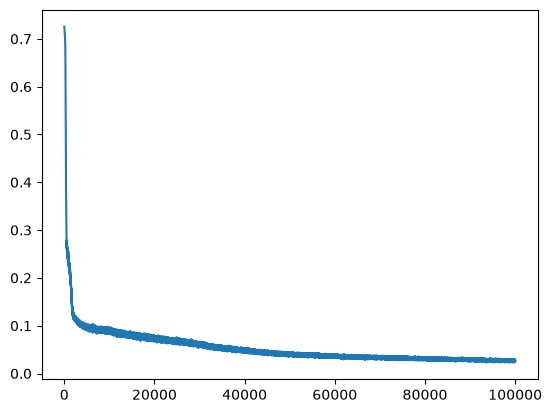

In [ ]:
hist_loss = train(
    model = plankton,
    opt = opt,
    data = data,
    loop = 100,
)

plt.plot(range(len(hist_loss)), hist_loss, label="loss")
print("End loss:", hist_loss[-1])

In [218]:
acc = torch.round(test_encoder(enc, dec, data))[0].sum((1, 2))
print(f"Accuracy: {acc}")

Test:   0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy: tensor([5., 1., 0., 1., 0., 1., 3., 0., 0., 0., 0., 0.], dtype=torch.float64)


# PlanktonAI training

In [ ]:
from torch.profiler import profile, ProfilerActivity

input = torch.rand(1, 1, 32)
plankton.cpu().eval()

with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as prof:
    plankton(input)

print(prof.key_averages().table(sort_by="cpu_time_total"))

In [ ]:
#Save
input = torch.rand(5, 1, 32)
plankton.cpu().eval()
onnx_plankton = onnx.dynamo_export(plankton, input)
onnx_plankton.save("plankton.onnx")
print("succses")